# Description
...

In [54]:
import pandas as pd
import plotly.express as px
from tqdm import tqdm
import numpy as np
import re
from scipy.stats import kendalltau

In [32]:
# Read in necessary tables

courses = pd.read_csv("data/courses.csv", sep=";", encoding="utf-8", index_col=0)
writers = pd.read_csv("data/writers.csv", sep=";", encoding="utf-8", index_col=0)
writer_counts = pd.read_csv("data/writer_counts.csv", sep=";", encoding="utf-8", index_col=0)

In [33]:
writers = writers.merge(right=writer_counts, right_index=True, left_on='GND-ID')
writers['gender'] = writers['gender'].map({'Weiblich': 'female', 'Männlich': 'male', 'Unbekannt': 'unknown'})

In [34]:
writers.head()

,GND-ID,Name_identifiziert,occupation_GND,birth_GND,gender,death_GND,country_GND,country_norm,total_graz,total_mainz,...,rel_marburg,rel_halle,rel_wien,rel_erfurt,total_A,total_S,total_G,rel_G,rel_A,rel_S
0,118544918,"Hahn-Hahn, Ida, Gräfin",Schriftsteller; Lyriker; Publizist; Nonne,1805-06-22,female,1880-01-12,Frankreich; Deutschland,D,0,0,...,0.0,0.000000,0.000000,0.000000,0,1,0,0.000000,0.000000,0.001605
1,118577166,"Mann, Thomas",Nobelpreisträger; Musiker; Intellektueller; Sc...,1875-06-06,male,1955-08-12,Deutschland; Japan; Europa; USA,"D,S",0,0,...,0.0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000
2,118570366,"Lawrence, Thomas E.",Schriftsteller; Offizier; Archäologe; Geheimagent,1888-08-16,male,1935-05-19,Großbritannien,NaN,0,0,...,0.0,0.000000,0.000000,0.006231,0,1,2,0.001038,0.000000,0.001605
3,133347931,"Borries, Friedrich von",Schriftsteller; Architekt,1974,male,NaN,Deutschland,D,0,0,...,0.0,0.001549,0.004261,0.000000,3,0,2,0.000258,0.002131,0.000000
4,118552465,"Hoffmann, E. T. A.",Komponist; Schriftsteller; Kapellmeister; Zeic...,1776-01-24,male,1822-06-25,Deutschland,D,0,0,...,0.0,0.001549,0.000000,0.000000,0,0,2,0.000258,0.000000,0.000000


# Top 20 for Austria, Germany and Switzerland


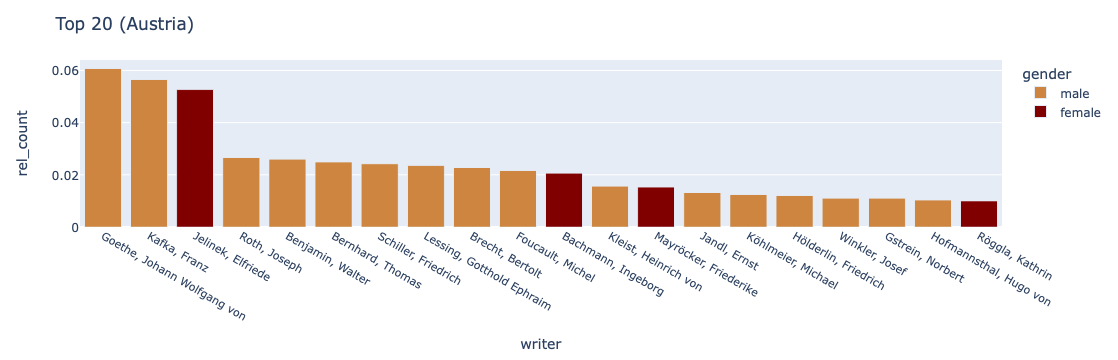

In [42]:
writers_short = writers.sort_values("rel_A", ascending=False).reset_index()[0:20]
fig = px.bar(writers_short, x="Name_identifiziert", y="rel_A", color="gender",\
             color_discrete_map={"male":"peru", "female":"maroon"})


fig.update_layout(xaxis={'categoryorder':'total descending', \
                  "tickfont" : dict(size=11)},
                 yaxis_title="rel_count",\
                 xaxis_title="writer",\
                 title="Top 20 (Austria)")

fig.write_image("figures/writers_statistics1.png", scale=2, height=400, width=900)
fig.show()

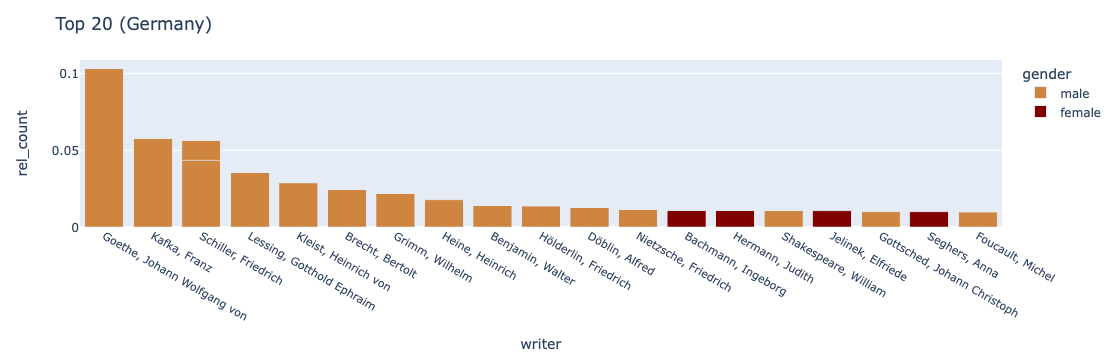

In [41]:
writers_short = writers.sort_values("rel_G", ascending=False).reset_index()[0:20]
fig = px.bar(writers_short, x="Name_identifiziert", y="rel_G", color="gender",\
             color_discrete_map={"male":"peru", "female":"maroon"})


fig.update_layout(xaxis={'categoryorder':'total descending', \
                  "tickfont" : dict(size=11)},
                 yaxis_title="rel_count",\
                 xaxis_title="writer",\
                 title="Top 20 (Germany)")

fig.write_image("figures/writers_statistics2.png", scale=2, height=400, width=900)
fig.show()

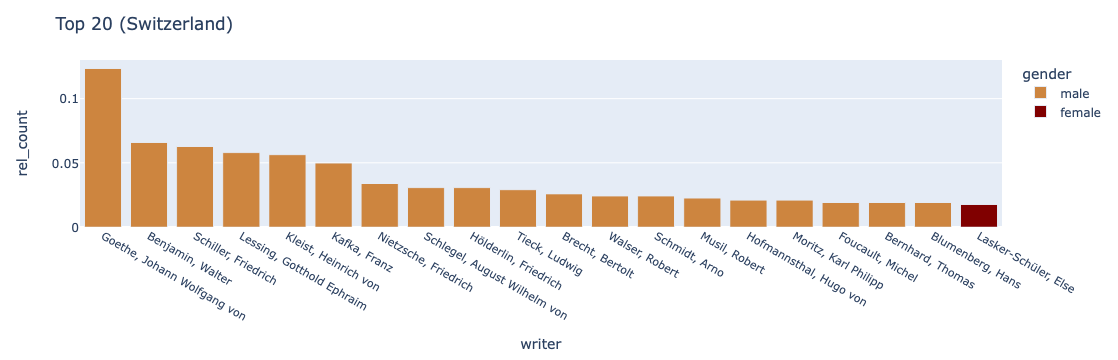

In [43]:
writers_short = writers.sort_values("rel_S", ascending=False).reset_index()[0:20]
fig = px.bar(writers_short, x="Name_identifiziert", y="rel_S", color="gender",\
             color_discrete_map={"male":"peru", "female":"maroon"})


fig.update_layout(xaxis={'categoryorder':'total descending', \
                  "tickfont" : dict(size=11)},
                 yaxis_title="rel_count",\
                 xaxis_title="writer",\
                 title="Top 20 (Switzerland)")

fig.write_image("figures/writers_statistics3.png", scale=2, height=400, width=900)
fig.show()

## Correlations

In [45]:
print("Correlation between relative counts for Switzerland and Germany", writers["rel_S"].corr(writers["rel_G"]))

Correlation between relative counts for Switzerland and Germany 0.8471254473815697


In [46]:
print("Correlation between relative counts for Austria and Germany", writers["rel_A"].corr(writers["rel_G"]))

Correlation between relative counts for Austria and Germany 0.7455908269997068


In [47]:
print("Correlation between relative counts for Switzerland and Austria", writers["rel_S"].corr(writers["rel_A"]))

Correlation between relative counts for Switzerland and Austria 0.6940776594046586


## Writers with high differences

In [48]:
writers.head()

,GND-ID,Name_identifiziert,occupation_GND,birth_GND,gender,death_GND,country_GND,country_norm,total_graz,total_mainz,...,rel_marburg,rel_halle,rel_wien,rel_erfurt,total_A,total_S,total_G,rel_G,rel_A,rel_S
0,118544918,"Hahn-Hahn, Ida, Gräfin",Schriftsteller; Lyriker; Publizist; Nonne,1805-06-22,female,1880-01-12,Frankreich; Deutschland,D,0,0,...,0.0,0.000000,0.000000,0.000000,0,1,0,0.000000,0.000000,0.001605
1,118577166,"Mann, Thomas",Nobelpreisträger; Musiker; Intellektueller; Sc...,1875-06-06,male,1955-08-12,Deutschland; Japan; Europa; USA,"D,S",0,0,...,0.0,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000
2,118570366,"Lawrence, Thomas E.",Schriftsteller; Offizier; Archäologe; Geheimagent,1888-08-16,male,1935-05-19,Großbritannien,NaN,0,0,...,0.0,0.000000,0.000000,0.006231,0,1,2,0.001038,0.000000,0.001605
3,133347931,"Borries, Friedrich von",Schriftsteller; Architekt,1974,male,NaN,Deutschland,D,0,0,...,0.0,0.001549,0.004261,0.000000,3,0,2,0.000258,0.002131,0.000000
4,118552465,"Hoffmann, E. T. A.",Komponist; Schriftsteller; Kapellmeister; Zeic...,1776-01-24,male,1822-06-25,Deutschland,D,0,0,...,0.0,0.001549,0.000000,0.000000,0,0,2,0.000258,0.000000,0.000000


In [52]:
# Differences Austria-Germany
writers['diff_A_G'] = writers['rel_A'] - writers['rel_G']
top_diff_rows = writers.nlargest(50, 'diff_A_G')
austrian = ["Ö", "D,Ö", "Ö,S", "D,Ö,S"]
proportion = len(top_diff_rows[top_diff_rows["country_norm"].isin(austrian)])/len(top_diff_rows)
print("Number of austrian writers in top 50 with highest differences (A-G): ", proportion)

Number of austrian writers in top 50 with highest differences:  0.9


In [30]:
top_diff_rows

,GND-NUmmer,Count,Rel_Count,Geschlecht,Name,Count_Ger,Rel_Count_Ger,Count_Austr,Rel_Count_Austr,Count_Suiss,Rel_Count_Suiss,German,Swiss,Austrian,Ländercode,Land,Diff_Austr_Ger
98,119001802,132,0.174828,Weiblich,"Jelinek, Elfriede",47,0.063237,81,0.105170,4,0.006421,1.0,0.0,1.0,Österreich; Deutschland,"D,Ö",0.041933
480,118603140,67,0.087623,Männlich,"Roth, Joseph",21,0.029496,43,0.053312,3,0.004815,1.0,0.0,1.0,Österreich; Frankreich; Deutschland; Ukraine,"D,Ö",0.023815
788,119544199,20,0.026722,Männlich,"Köhlmeier, Michael",1,0.001852,19,0.024870,0,0.000000,0.0,0.0,1.0,Österreich,Ö,0.023018
428,118556894,23,0.030189,Männlich,"Jandl, Ernst",2,0.003890,21,0.026299,0,0.000000,0.0,0.0,1.0,Österreich,Ö,0.022409
1378,118881140,19,0.022045,Männlich,"Winkler, Josef",0,0.000000,19,0.022045,0,0.000000,0.0,0.0,1.0,Österreich,Ö,0.022045
1385,11894293X,20,0.023897,Männlich,"Gstrein, Norbert",1,0.001852,19,0.022045,0,0.000000,0.0,0.0,1.0,Österreich,Ö,0.020194
1518,118732404,34,0.042737,Weiblich,"Mayröcker, Friederike",8,0.010564,25,0.030568,1,0.001605,0.0,0.0,1.0,Österreich,Ö,0.020004
1407,118710761,14,0.019180,Männlich,"Innerhofer, Franz",0,0.000000,14,0.019180,0,0.000000,0.0,0.0,1.0,Österreich,Ö,0.019180
698,118597914,20,0.023250,Männlich,"Raimund, Ferdinand",2,0.001549,16,0.018490,2,0.003210,0.0,0.0,1.0,Österreich,Ö,0.016941
218,129853666,14,0.016356,Weiblich,"Flor, Olga",0,0.000000,14,0.016356,0,0.000000,0.0,0.0,1.0,Österreich,Ö,0.016356


In [53]:
# Differences Switzerland-Germany
writers['diff_S_G'] = writers['rel_S'] - writers['rel_G']
top_diff_rows = writers.nlargest(50, 'diff_S_G')
swiss = ["S", "D,S", "Ö,S", "D,Ö,S"]
proportion = len(top_diff_rows[top_diff_rows["country_norm"].isin(swiss)])/len(top_diff_rows)
print("Number of swiss writers in top 50 with highest differences (S-G): ", proportion)

Number of swiss writers in top 50 with highest differences (S-G):  0.28


# Kendalls tau

In [57]:
print("Austria and Germany")
correlation, p_value = kendalltau(writers['rel_A'], writers['rel_G'])
print(f"Kendall correlation: {correlation}, p-value: {p_value}")

Austria and Germany
Kendall correlation: -0.10809542563980105, p-value: 5.5342248440558e-09


In [58]:
print("Austria and Suisse")
correlation, p_value = kendalltau(writers['rel_A'], writers['rel_S'])
print(f"Kendall correlation: {correlation}, p-value: {p_value}")

Austria and Suisse
Kendall correlation: 0.09242000579944747, p-value: 9.14978484683255e-06


In [59]:
print("Ger and Suisse")
correlation, p_value = kendalltau(writers['rel_G'], writers['rel_S'])
print(f"Kendall correlation: {correlation}, p-value: {p_value}")

Ger and Suisse
Kendall correlation: 0.11434081285308001, p-value: 6.546370451775831e-09


# Kendalls tau for respective top 50

In [61]:
# Get top 50 for each contry
top_50_G = writers.nlargest(50, 'rel_G')
top_50_S = writers.nlargest(50, 'rel_S')
top_50_A = writers.nlargest(50, 'rel_A')

# Concatenate the top 50 for each country into one and remove duplicates
top_50_authors = pd.concat([top_50_G, top_50_S, top_50_A])
top_50_authors = top_50_authors.drop_duplicates()

top_50_authors.reset_index(drop=True, inplace=True)

In [62]:

print("Austria and Germany")
correlation, p_value = kendalltau(top_50_authors['rel_A'], top_50_authors['rel_G'])
print(f"Kendall correlation: {correlation}, p-value: {p_value}")

print("Austria and Suisse")
correlation, p_value = kendalltau(top_50_authors['rel_A'], top_50_authors['rel_S'])
print(f"Kendall correlation: {correlation}, p-value: {p_value}")

print("Ger and Suisse")
correlation, p_value = kendalltau(top_50_authors['rel_G'], top_50_authors['rel_S'])
print(f"Kendall correlation: {correlation}, p-value: {p_value}")

Austria and Germany
Kendall correlation: 0.11242919803438697, p-value: 0.10583962750351926
Austria and Suisse
Kendall correlation: 0.07152160317941356, p-value: 0.32165809489398856
Ger and Suisse
Kendall correlation: 0.3963350114074197, p-value: 3.93699275886679e-08
